# Context

A synthetic dataset generated using the simulator called PaySim. PaySim uses aggregated data from the private dataset to generate a synthetic dataset that resembles the normal operation of transactions and injects malicious behaviour to later evaluate the performance of fraud detection methods.

PaySim simulates mobile money transactions based on a sample of real transactions extracted from one month of financial logs from a mobile money service implemented in an African country. The original logs were provided by a multinational company, who is the provider of the mobile financial service which is currently running in more than 14 countries all around the world.

This synthetic dataset is scaled down 1/4 of the original dataset and it is created just for [Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1).

# Objective

To flag anomaly

# Data Description

**NOTE: Transactions which are detected as fraud are cancelled, so for fraud detection these columns (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest ) must not be used.**

- `step`: maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).
- `type`:  CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
- `amount`: amount of the transaction in local currency.
- `nameOrig`: customer who started the transaction
- `oldbalanceOrg`: initial balance before the transaction
- `newbalanceOrig`: new balance after the transaction.
- `nameDest`: customer who is the recipient of the transaction
- `oldbalanceDest`: initial balance recipient before the transaction. Note that there is no information for customers that start with M (Merchants).
- `newbalanceDest`: new balance recipient after the transaction. Note that there is no information for customers that start with M (Merchants).
- `isFraud`: This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control of customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.
- `isFlaggedFraud`: The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200,000 in a single transaction.

# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)    
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# Functions

## Plots

In [2]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [3]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [4]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [5]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

# Load Data

In [6]:
data = pd.read_csv('PS_20174392719_1491204439457_log.csv')

In [7]:
df = data.copy()

# Data Overview

In [8]:
df.shape

(6362620, 11)

In [9]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0


In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,243.40,179861.90,833883.10,855113.67,1100701.67,1224996.40,0.00,0.00
std,142.33,603858.23,2888242.67,2924048.50,3399180.11,3674128.94,0.04,0.00
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,156.00,13389.57,0.00,0.00,0.00,0.00,0.00,0.00
50%,239.00,74871.94,14208.00,0.00,132705.66,214661.44,0.00,0.00
75%,335.00,208721.48,107315.18,144258.41,943036.71,1111909.25,0.00,0.00
max,743.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92,1.00,1.00


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


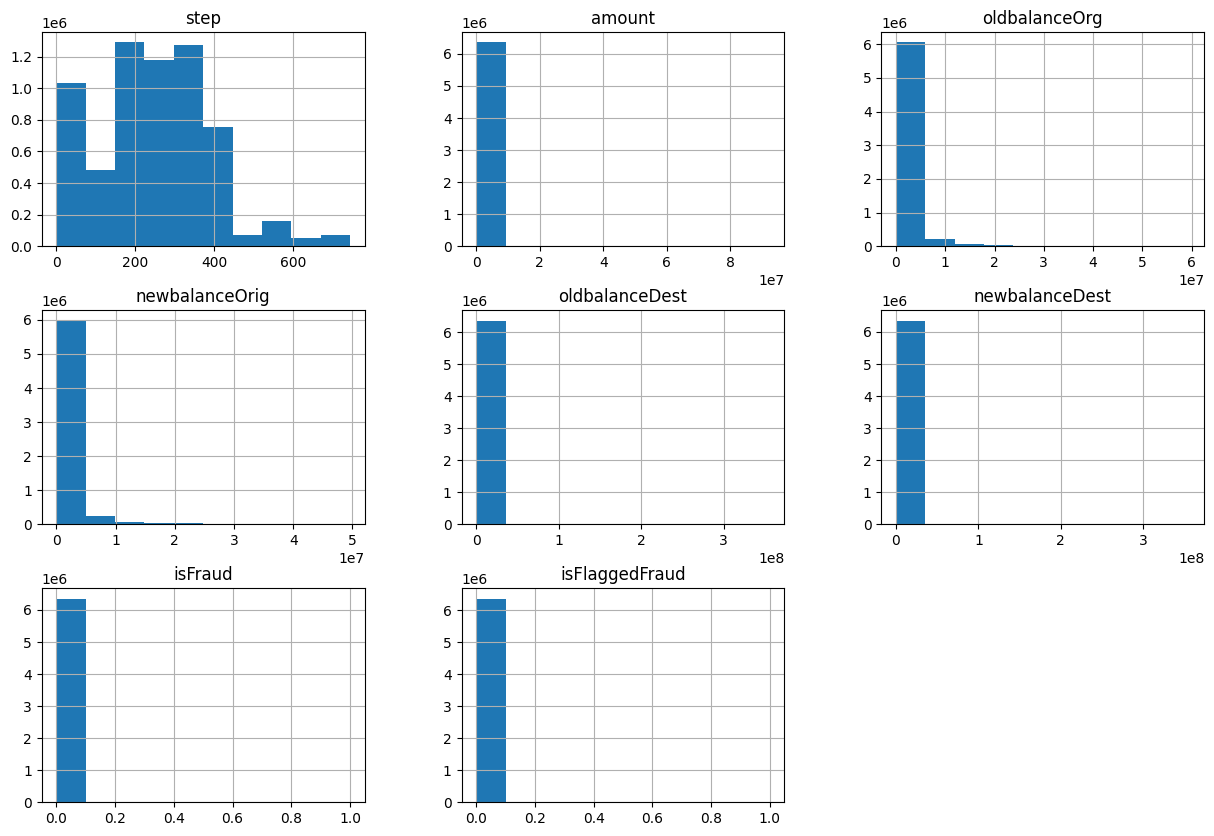

In [14]:
df.hist(figsize=(15,10))
plt.show()

In [15]:
df[df['isFraud'] == 1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [16]:
print('The % of fraud transaction is', round(df[df['isFraud'] == 1].shape[0] / df.shape[0] *100,4),'%')

The % of fraud transaction is 0.1291 %


In [17]:
df[df['isFlaggedFraud'] == 1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.00,0.00,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.00,0.00,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.00,0.00,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.00,0.00,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.00,0.00,1,1
5996409,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.00,0.00,1,1
6168499,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.00,0.00,1,1
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.00,0.00,1,1
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.00,0.00,1,1
6281482,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.00,0.00,1,1


In [18]:
print('The % of fraud transaction flagged is', round(df[df['isFlaggedFraud'] == 1].shape[0] / df.shape[0] *100,6),'%')

The % of fraud transaction flagged is 0.000251 %


In [19]:
num_column = df.describe(include = np.number).columns
num_column

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

# EDA

## Univariate

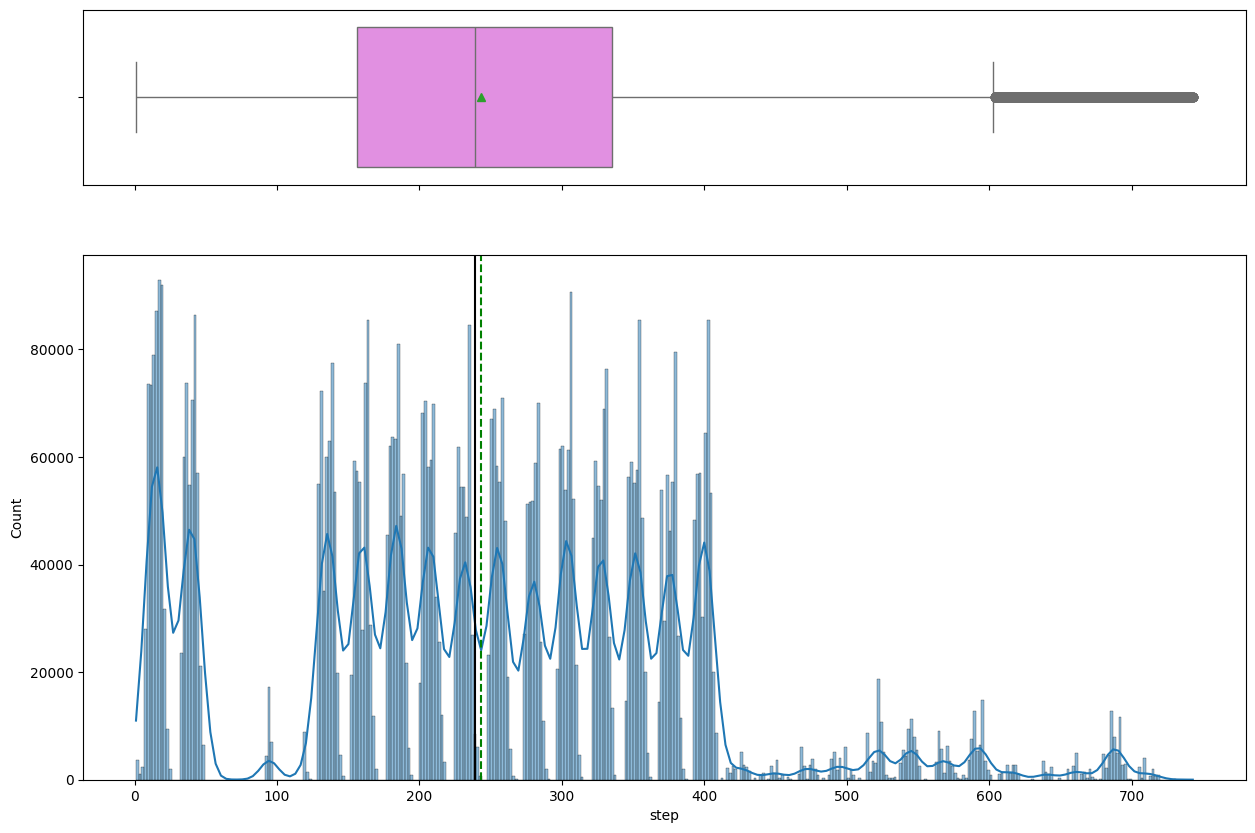

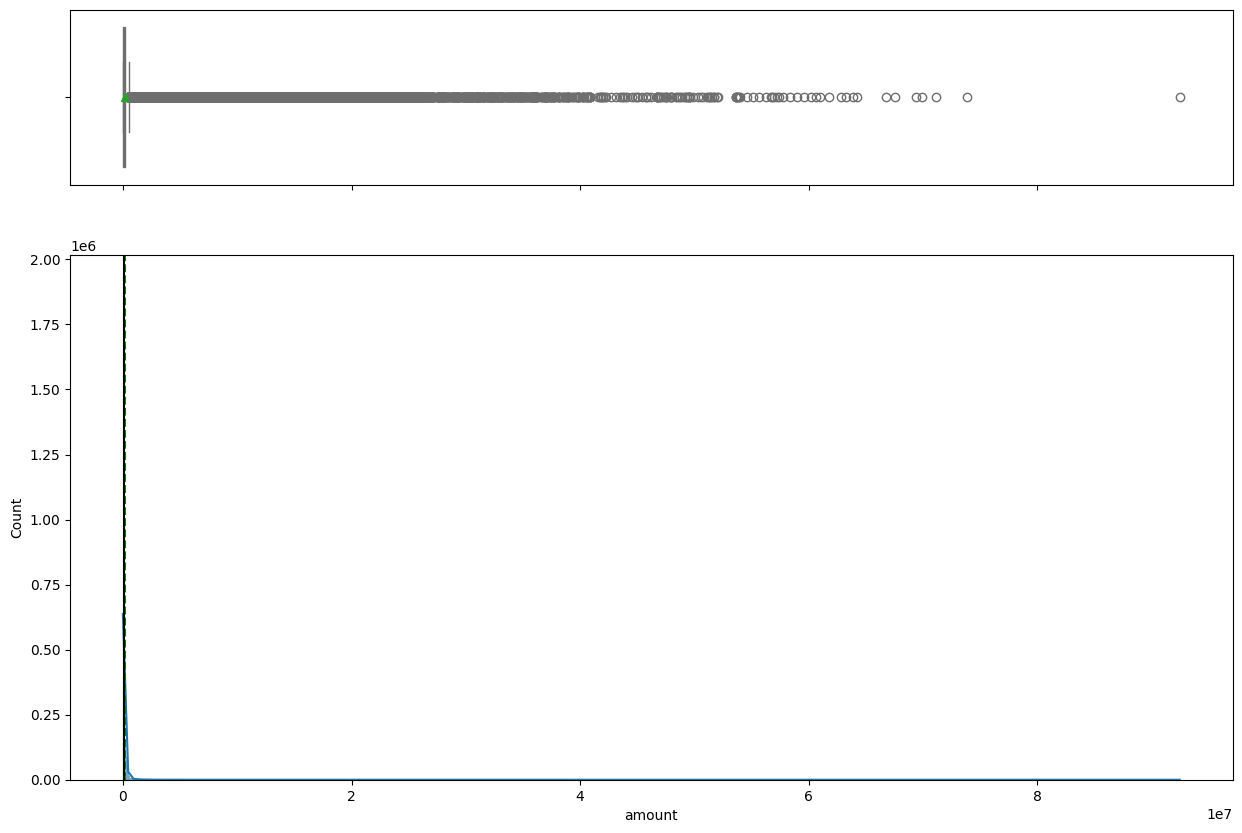

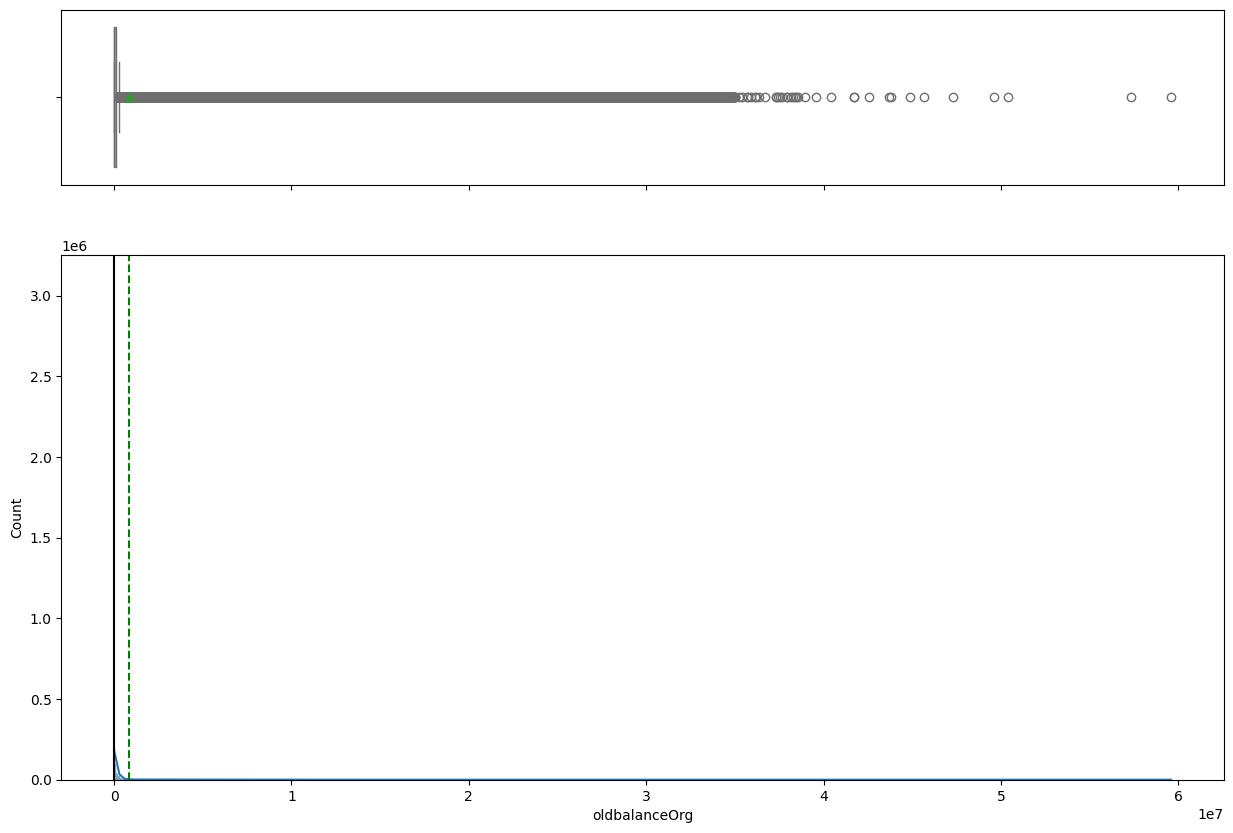

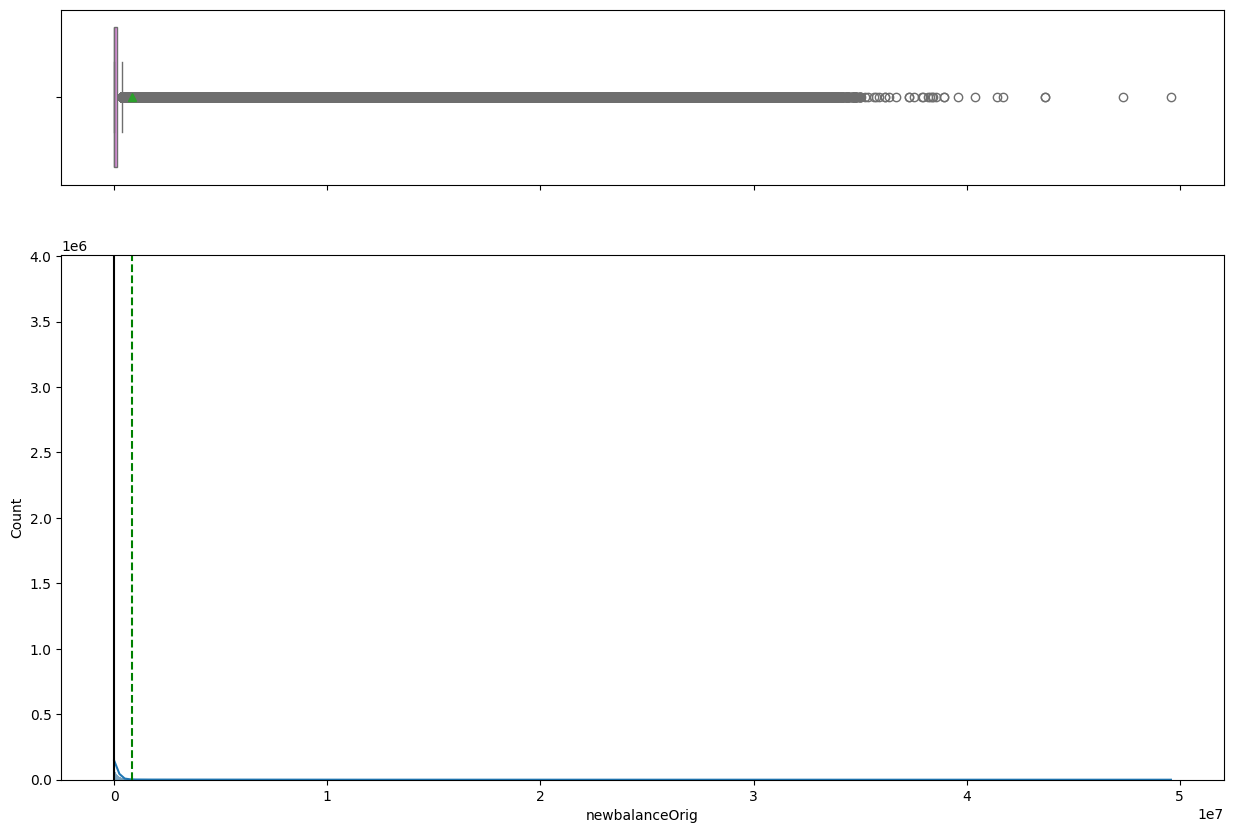

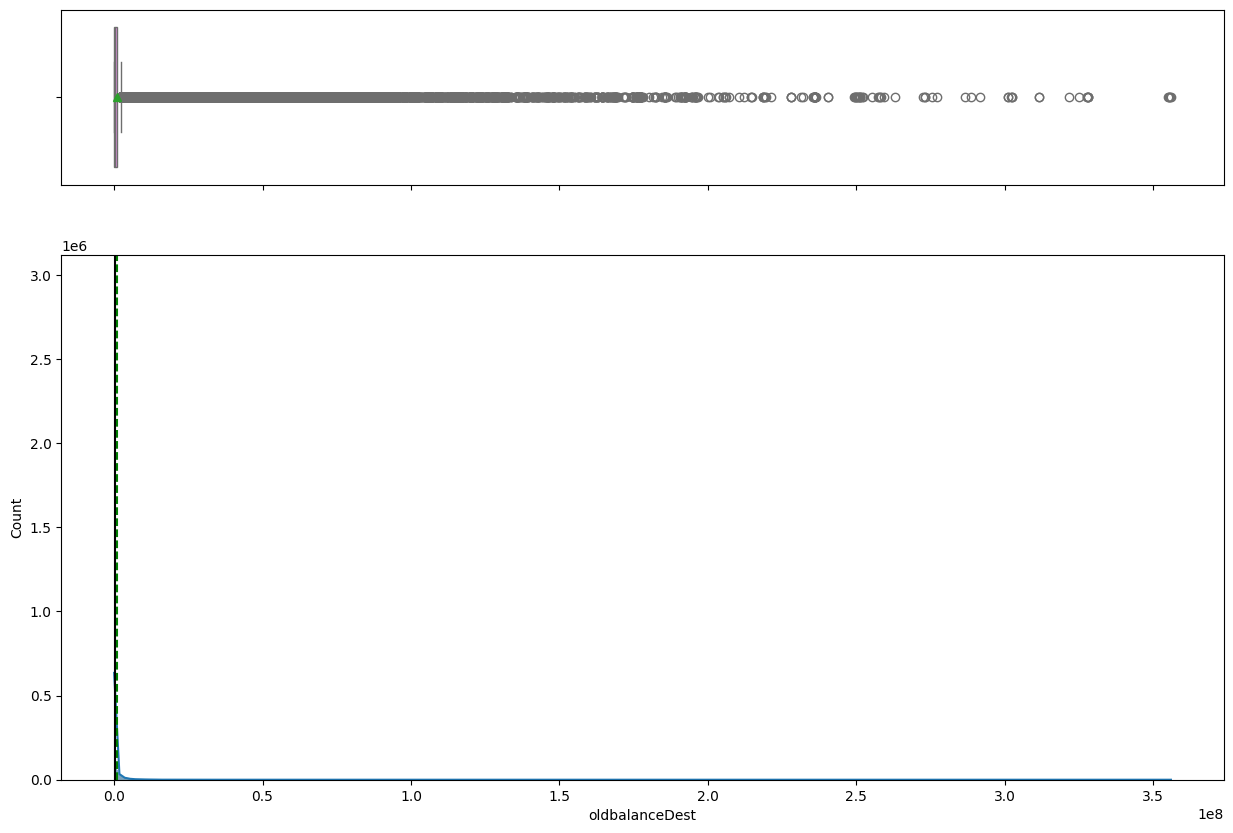

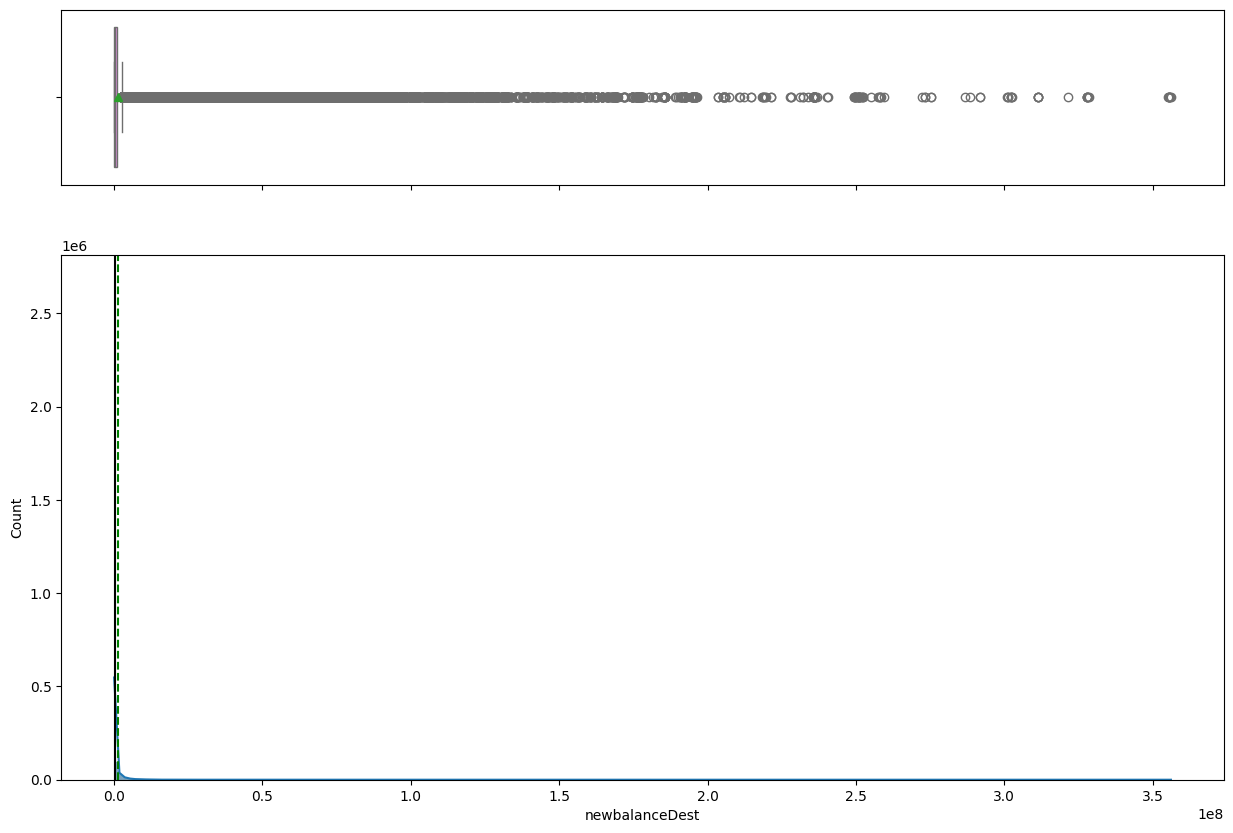

In [20]:
for i in num_column.drop(['isFraud','isFlaggedFraud']):
    histogram_boxplot(df, i, figsize=(15, 10), kde=True, bins=None)

**Observations:**

`step`
- Time based, there's pattern when no transaction is done.
- A lot of transaction during the first half of the month and the number of transactions decreased dramatically on the second half of the month.

`amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`
- Extreme outliers.

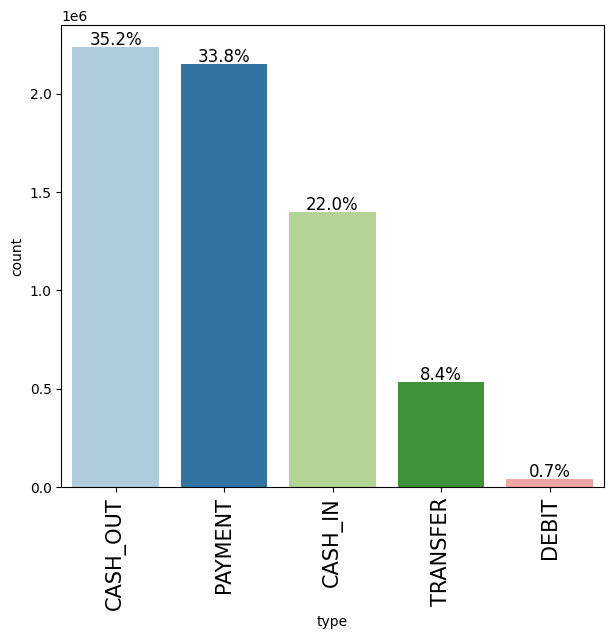

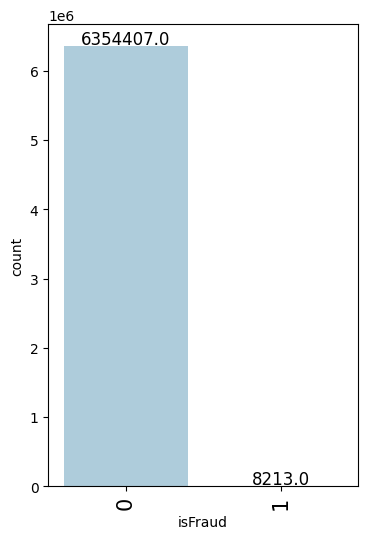

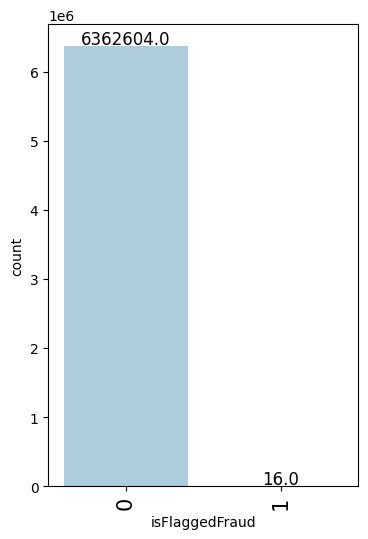

In [21]:
labeled_barplot(df, 'type',perc=True)
labeled_barplot(df, 'isFraud',perc=False)
labeled_barplot(df, 'isFlaggedFraud',perc=False)

**Observations:**

`type`
- 8.4% of the transaction type is through transfer, which is the primary category for fraud flagging.

`isFraud`
- 0.1291% of the transaction is fraud. Heavily imbalanced

`isFlaggedFraud`
- 0.000251% of the transaction is flagged fraud.

## Multivariate

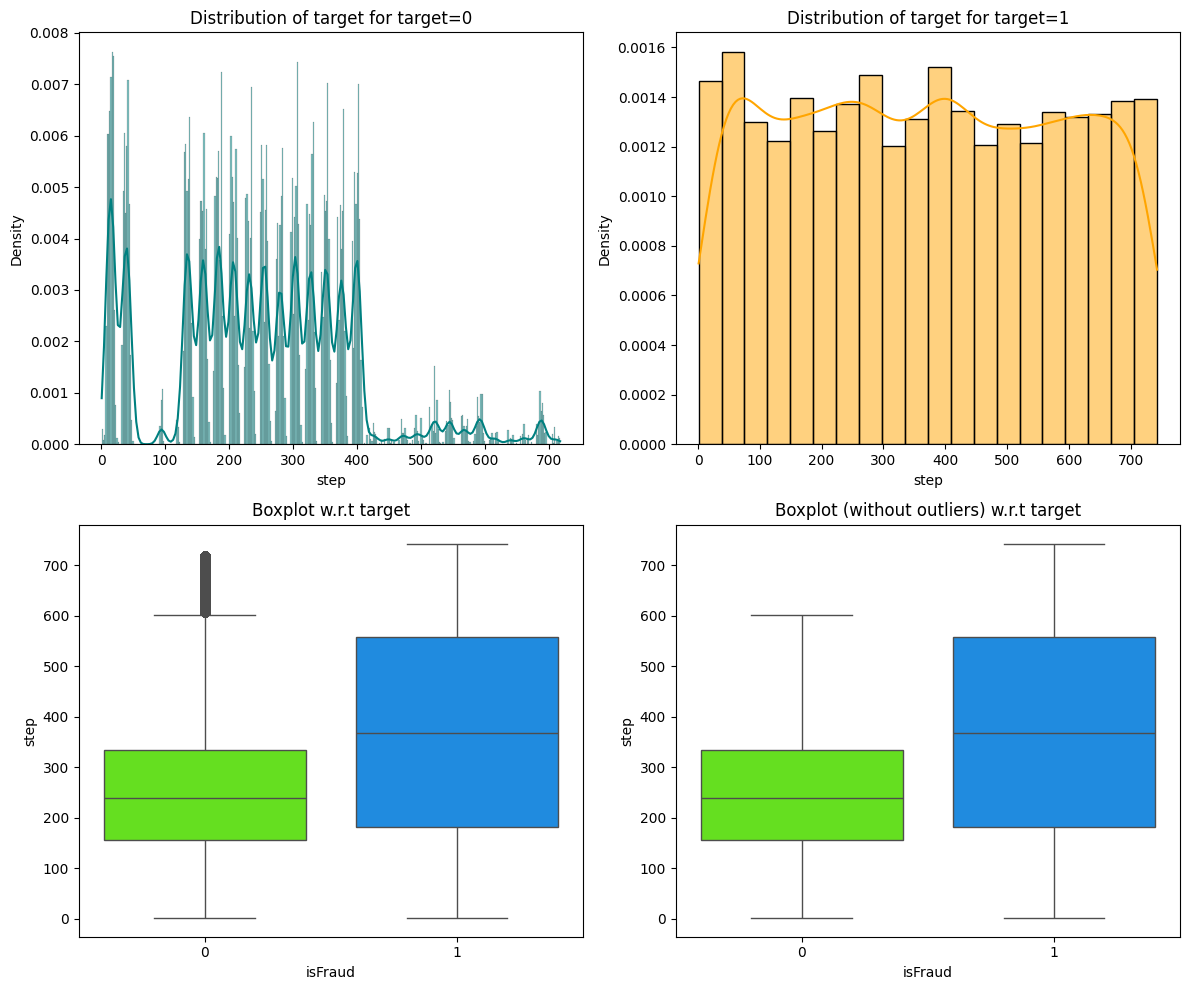

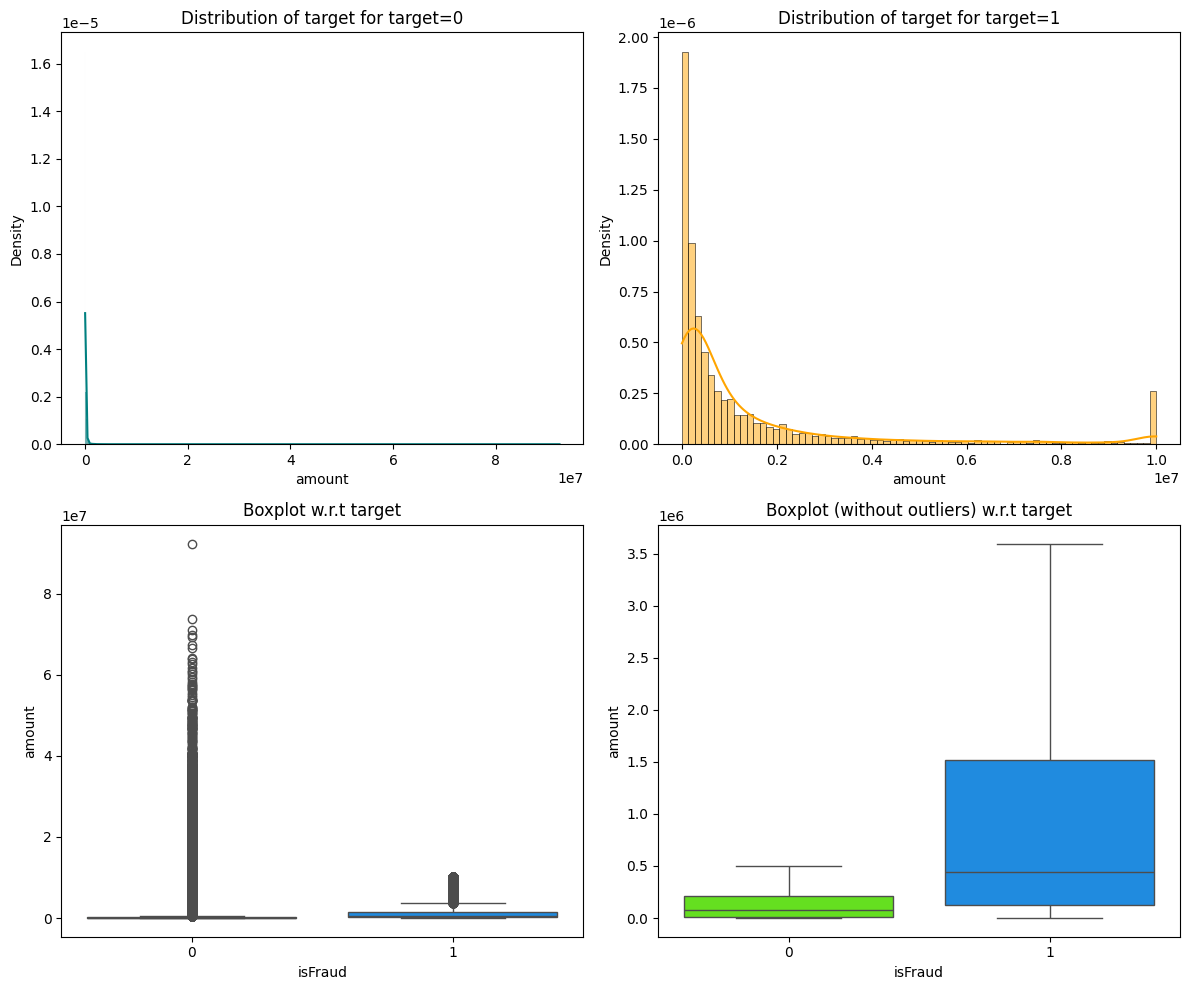

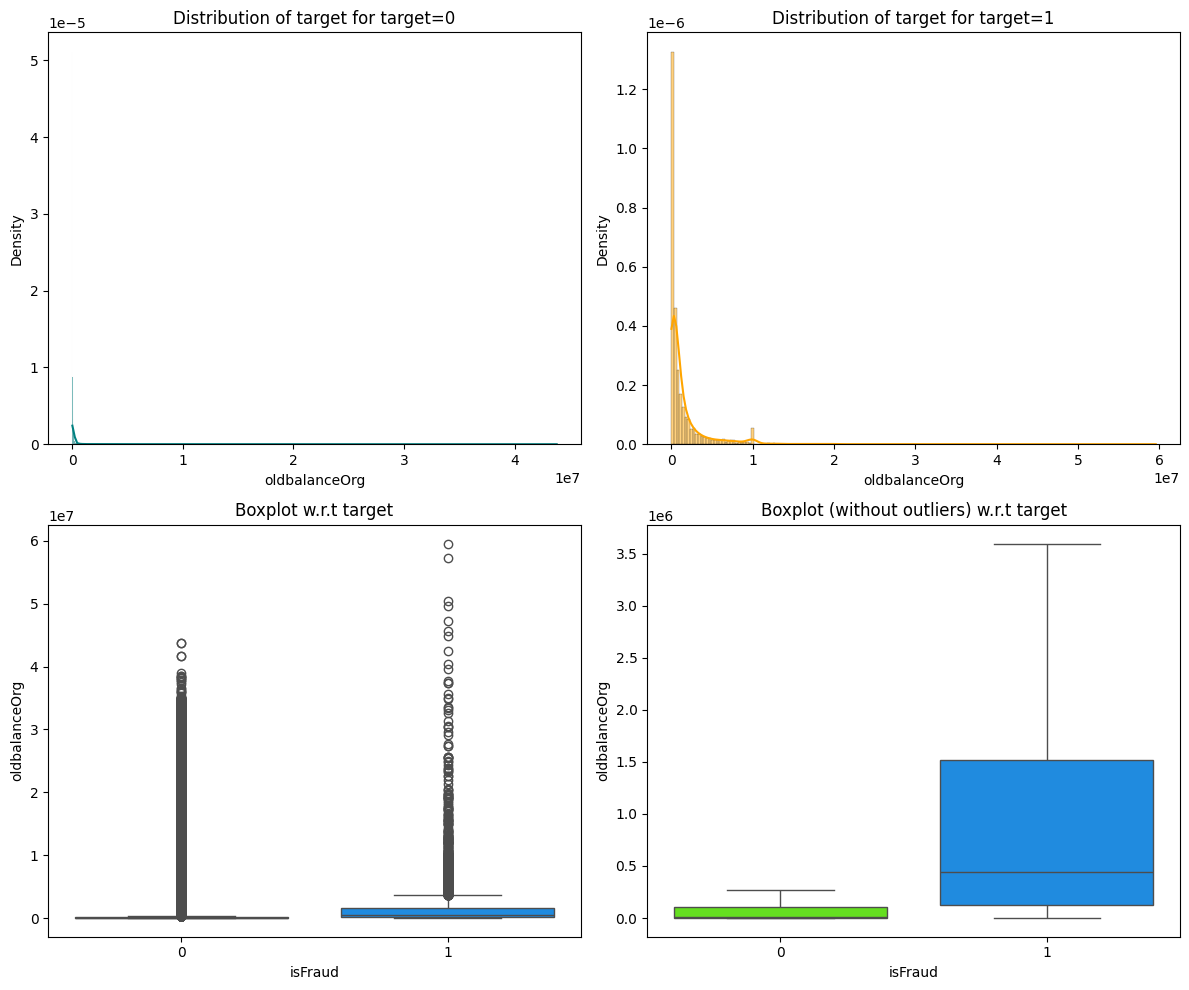

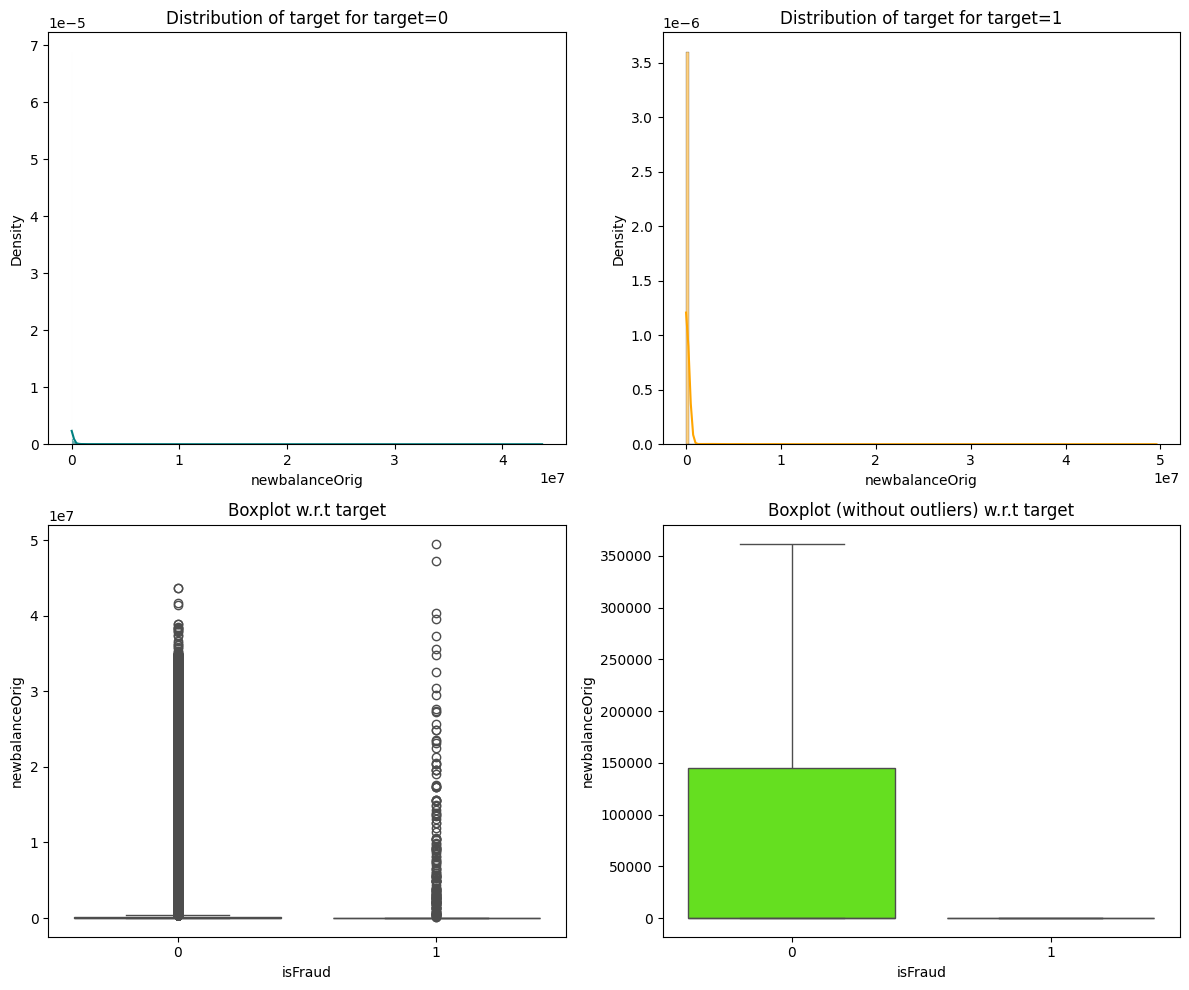

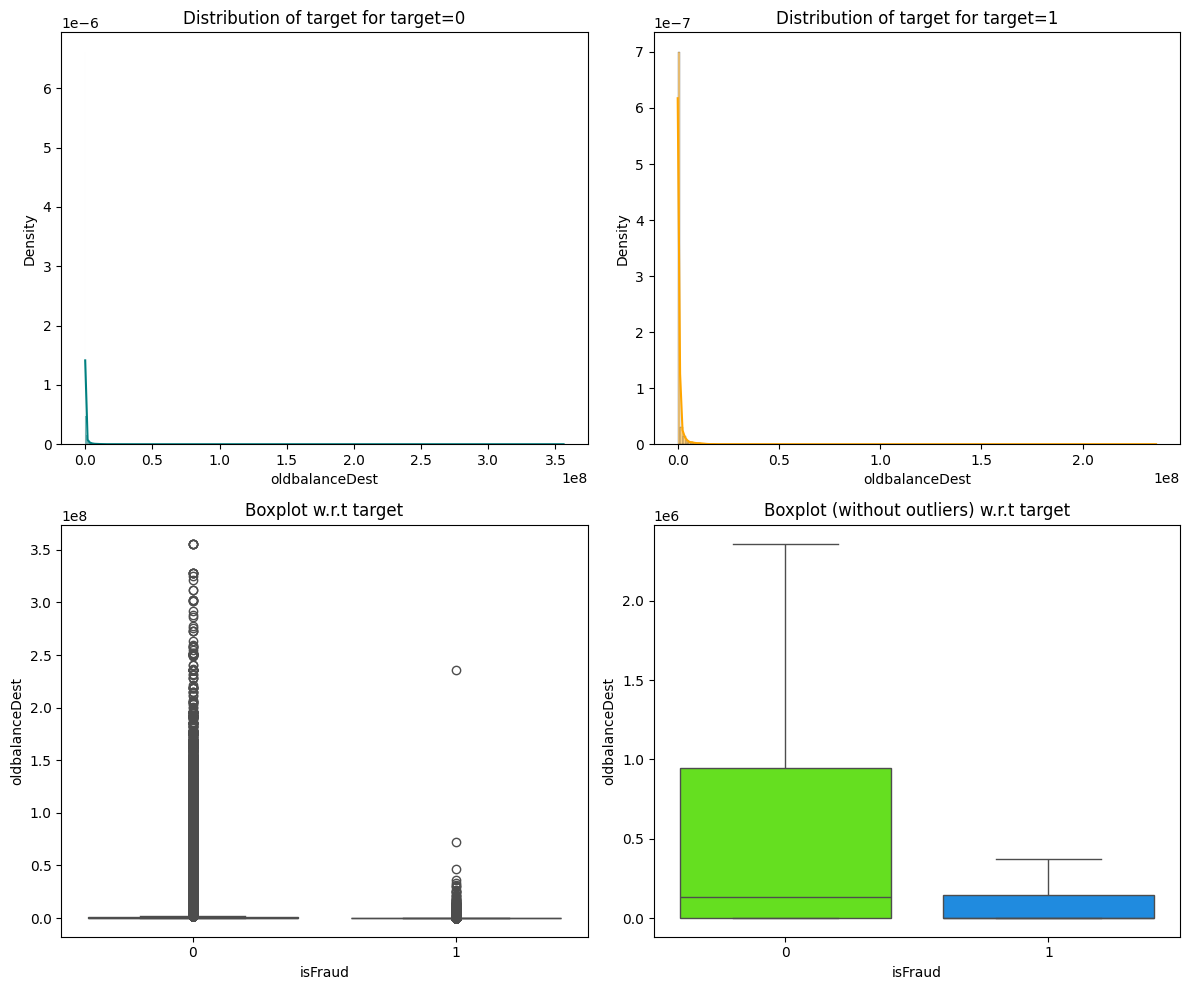

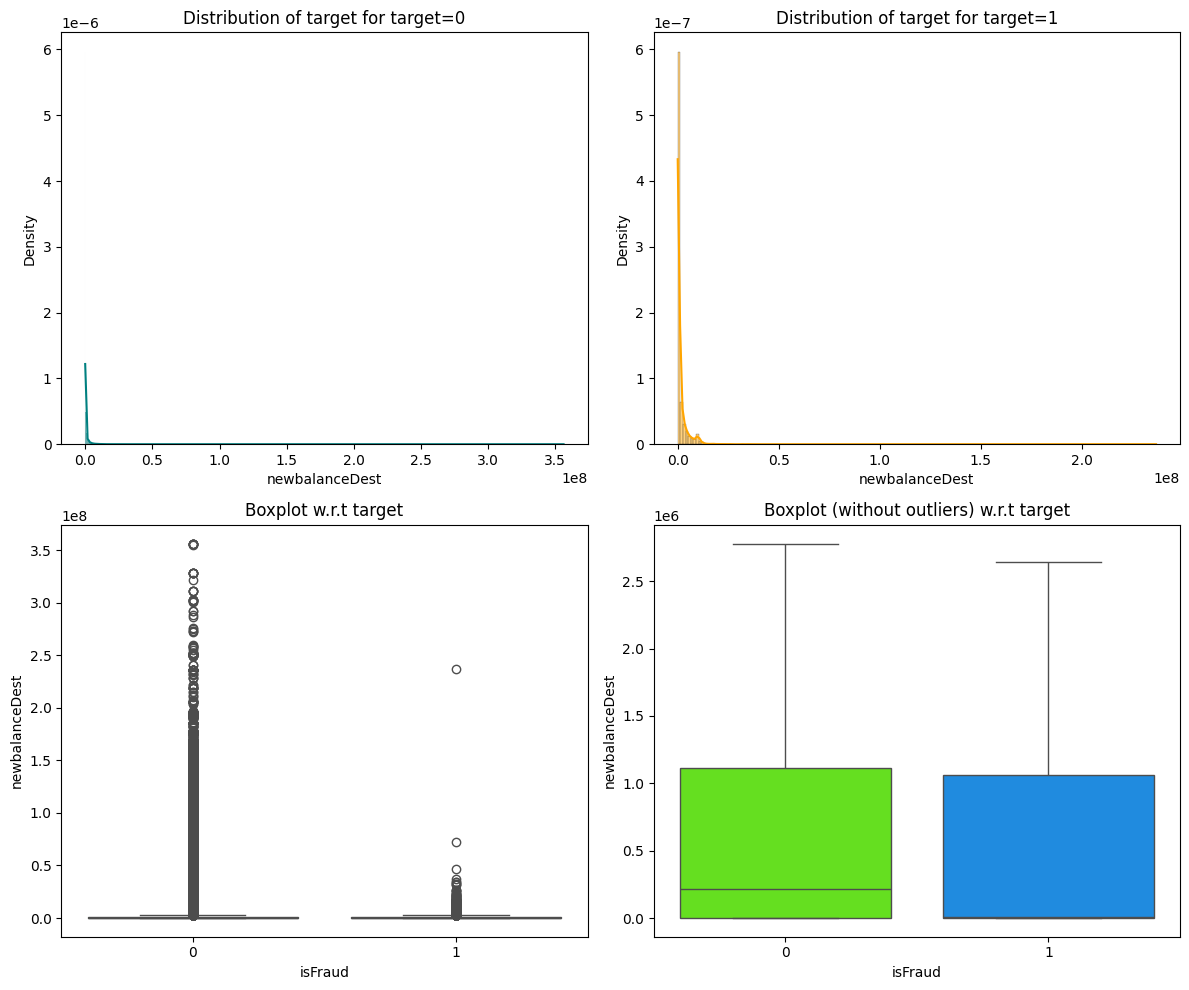

In [23]:
for i in num_column.drop(['isFraud','isFlaggedFraud']):
    distribution_plot_wrt_target(df, i, 'isFraud')

**Observations on `isFraud` as our target:**

`step`
- the detected fraud are uniformly distributed over time.

`amount`
- the amount distribution is heavily right-skewed.
- Interesting that fraud is right-skewed, meaning there are a significant number of transaction have small amount.
- It is also observed that amount is overall higher compare to non-fraud transaction, counter intuitive.

`oldbalanceOrg`
- heavily skewed to the right.
- Detected fraud has overall higher balance.

`newbalanceOrg`
- heavily right-skewed.
- Detected fraud has very small amount on new balance, very intuitive that money has all been transferred.

`oldbalanceDest`
- heavily skewed to the right.
- Detected fraud has low balance.

`newbalanceDest`
- heavily skewed to the right.
- The new balance has increased significantly compared to old balance. Its a clear pattern fraud transaction had happened.

isFraud         0     1      All
type                            
All       6354407  8213  6362620
CASH_OUT  2233384  4116  2237500
TRANSFER   528812  4097   532909
CASH_IN   1399284     0  1399284
PAYMENT   2151495     0  2151495
DEBIT       41432     0    41432
------------------------------------------------------------------------------------------------------------------------


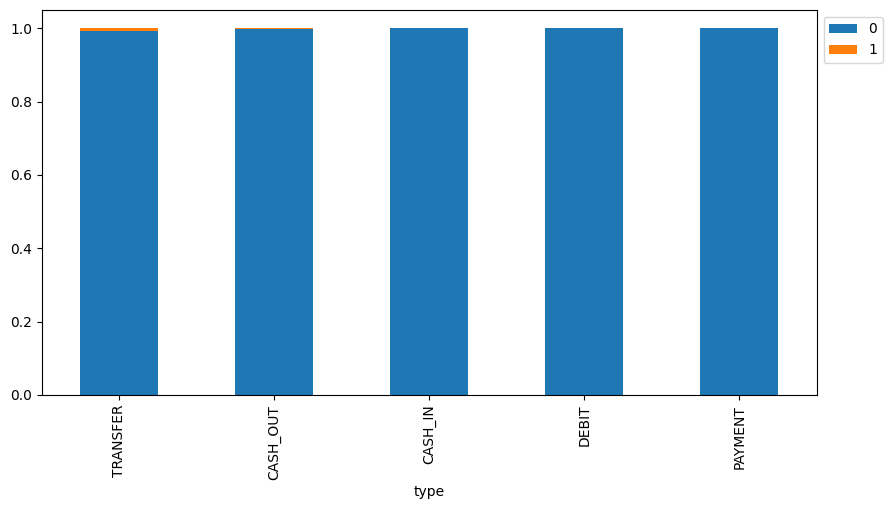

In [24]:
stacked_barplot(df, 'type', 'isFraud')

isFlaggedFraud        0   1      All
type                                
TRANSFER         532893  16   532909
All             6362604  16  6362620
CASH_OUT        2237500   0  2237500
CASH_IN         1399284   0  1399284
PAYMENT         2151495   0  2151495
DEBIT             41432   0    41432
------------------------------------------------------------------------------------------------------------------------


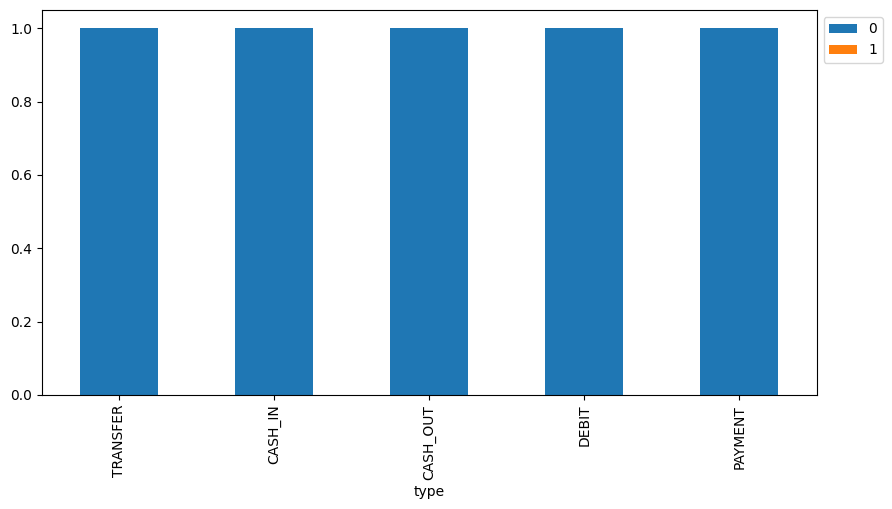

In [25]:
stacked_barplot(df, 'type', 'isFlaggedFraud')

In [33]:
print(df.groupby('type')['isFraud'].mean() * 100)

type
CASH_IN    0.00
CASH_OUT   0.18
DEBIT      0.00
PAYMENT    0.00
TRANSFER   0.77
Name: isFraud, dtype: float64


**Observations:**

- The detected fraud appears to be only in the form of CASH_OUT and TRANSFER method. 
- Around 50% of the fraud detected are TRANSFER, same as CASH_OUT.
- The fraud rate is higher in TRANSFER, 0.77%.
- CASH_OUT is of 0.18% default rate.

## Time series

In [26]:
df.groupby('step')['amount'].sum()

step
1     285429181.15
2      85921604.02
3      43293884.42
4      72910028.57
5      45548089.75
          ...     
739    16587831.36
740     7632963.58
741    87828992.99
742    14323735.20
743    17519825.50
Name: amount, Length: 743, dtype: float64

<Axes: xlabel='step'>

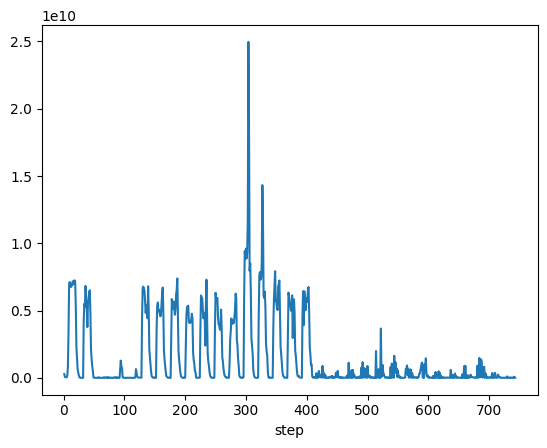

In [27]:
df.groupby('step')['amount'].sum().plot()

- Heavy activity in the first 400 hours. Tapered down to 0 after that.

In [28]:
for i in range(0, 744, 168):
    bin_end = min(i + 168, 744)
    counts = df[df['step'].between(i, bin_end)]['isFraud'].value_counts()
    print(f"Step {i}-{bin_end}: Fraud={counts.get(1)}, Legit={counts.get(0)}")

Step 0-168: Fraud=1904, Legit=1928276
Step 168-336: Fraud=1865, Legit=2856554
Step 336-504: Fraud=1872, Legit=1280321
Step 504-672: Fraud=1802, Legit=230343
Step 672-744: Fraud=808, Legit=65794


In [29]:
df[df['step'].between(300, 400)].groupby('type')['amount'].sum()

type
CASH_IN     67089112746.00
CASH_OUT   108962030082.24
DEBIT          65053228.46
PAYMENT      9186833478.91
TRANSFER   218429417481.00
Name: amount, dtype: float64

In [30]:
for i in range(0, 744, 168):
    bin_end = min(i + 168, 744)
    counts = df[df['step'].between(i, bin_end)].groupby('type')['amount'].sum()
    print(f"Step {i}-{bin_end}: CASH_OUT={counts.get(1)}, TRANSFER={counts.get(4)}")

Step 0-168: CASH_OUT=127051359644.66, TRANSFER=102333968097.95
Step 168-336: CASH_OUT=171881363170.27, TRANSFER=261674625838.6
Step 336-504: CASH_OUT=78115384412.44, TRANSFER=101135834801.69
Step 504-672: CASH_OUT=13215983340.03, TRANSFER=15965919970.2
Step 672-744: CASH_OUT=4400991988.79, TRANSFER=4666701236.1


- The amount of the transaction doesn't seem to act as a signal for fraud.

In [31]:
for i in range(0, 744, 168):
    bin_end = min(i + 168, 744)
    subset = df[df['step'].between(i, bin_end)]
    rate = subset['isFraud'].mean() * 100
    print(f"Step {i}-{bin_end}: Fraud rate = {rate:.4f}%")

Step 0-168: Fraud rate = 0.0986%
Step 168-336: Fraud rate = 0.0652%
Step 336-504: Fraud rate = 0.1460%
Step 504-672: Fraud rate = 0.7762%
Step 672-744: Fraud rate = 1.2132%


- Fraud rate actually increases weekly.

# Summary findings

- `step` will be an important feature as there is an increasing fraud rate pattern.
- `type` only CASH_OUT and TRANSFER is important for the analysis.
- Heavily imbalanced data
- We proceed with further analysis in the next notebook.